In [23]:
# ==========================================================
# CELDA 1 - IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# ==========================================================
# CELDA 2 - CARGAR DATASET LIMPIO
# ==========================================================

dataset_path = r"E:\Proyectos_GitHub\Procesamiento\CSV_Output\dataset_limpio.csv"

df = pd.read_csv(dataset_path)

print("Dataset cargado correctamente.")
print(df.shape)

df.head()

Dataset cargado correctamente.
(1028211, 52)


,id,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_duration_ms,dst2src_packets,...,src2dst_psh_packets,src2dst_rst_packets,src2dst_fin_packets,dst2src_syn_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_fin_packets,application_is_guessed,application_confidence,Label
0,0,17,23,2,156,0,1,70,0,1,...,0,0,0,0,0,0,0,0,6,Benign
1,1,1,4005,5,390,4005,5,390,0,0,...,0,0,0,0,0,0,0,0,6,Benign
2,2,6,126,4,515,126,4,515,0,0,...,1,0,1,0,0,0,0,0,6,Benign
3,3,6,418,10,1247,275,5,534,251,5,...,1,0,1,1,5,1,1,0,6,Benign
4,4,17,22,2,156,0,1,70,0,1,...,0,0,0,0,0,0,0,0,6,Benign


In [25]:
# ==========================================================
# CELDA 3 - VERIFICAR TIPOS DE DATOS
# ==========================================================

print(df.dtypes)

print("\nResumen de tipos:\n")

print(df.dtypes.value_counts())

id                                int64
protocol                          int64
bidirectional_duration_ms         int64
bidirectional_packets             int64
bidirectional_bytes               int64
src2dst_duration_ms               int64
src2dst_packets                   int64
src2dst_bytes                     int64
dst2src_duration_ms               int64
dst2src_packets                   int64
dst2src_bytes                     int64
bidirectional_min_ps              int64
bidirectional_mean_ps           float64
bidirectional_stddev_ps         float64
bidirectional_max_ps              int64
src2dst_min_ps                    int64
src2dst_mean_ps                 float64
src2dst_stddev_ps               float64
src2dst_max_ps                    int64
dst2src_min_ps                    int64
dst2src_mean_ps                 float64
dst2src_stddev_ps               float64
dst2src_max_ps                    int64
bidirectional_min_piat_ms         int64
bidirectional_mean_piat_ms      float64


In [27]:
# ==========================================================
# CELDA 4 - SEPARAR TRÁFICO BENIGNO Y ATAQUES
# ==========================================================

# Tráfico benigno
benign_df = df[df["Label"] == "Benign"]

# Tráfico malicioso
attack_df = df[df["Label"] != "Benign"]

print("Benign:", benign_df.shape)

print("Ataques:", attack_df.shape)

Benign: (240997, 52)
Ataques: (787214, 52)


In [28]:
# ==========================================================
# CELDA 5 - TRAIN / TEST SPLIT
# ==========================================================

# Dividir SOLO tráfico benigno
train_benign, test_benign = train_test_split(
    benign_df,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

print("Train benign:", train_benign.shape)

print("Test benign:", test_benign.shape)

Train benign: (168697, 52)
Test benign: (72300, 52)


In [29]:
# ==========================================================
# CELDA 6 - CREAR DATASET DE PRUEBA
# ==========================================================

# Dataset final de prueba
test_df = pd.concat(
    [test_benign, attack_df],
    ignore_index=True
)

print("Dataset de prueba:")
print(test_df.shape)

Dataset de prueba:
(859514, 52)


In [30]:
# ==========================================================
# CELDA 7 - SEPARAR FEATURES Y LABELS
# ==========================================================

# TRAIN
X_train = train_benign.drop(columns=["Label"])

# TEST
X_test = test_df.drop(columns=["Label"])

# Etiquetas reales
y_test = test_df["Label"]

print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

X_train: (168697, 51)
X_test: (859514, 51)


In [31]:
# ==========================================================
# CELDA 8 - NORMALIZACIÓN MIN-MAX
# ==========================================================

# Crear scaler
scaler = MinMaxScaler()

# AJUSTAR SOLO CON BENIGN TRAIN
X_train_scaled = scaler.fit_transform(X_train)

# TRANSFORMAR TEST
X_test_scaled = scaler.transform(X_test)

print("Normalización completada.")

Normalización completada.


In [32]:
# ==========================================================
# CELDA 9 - CONVERTIR A FLOAT32
# ==========================================================

X_train_scaled = X_train_scaled.astype(np.float32)

X_test_scaled = X_test_scaled.astype(np.float32)

print("Conversión a float32 completada.")

Conversión a float32 completada.


In [33]:
# ==========================================================
# CELDA 10 - CONSTRUIR AUTOENCODER
# ==========================================================

input_dim = X_train_scaled.shape[1]

# Entrada
input_layer = Input(shape=(input_dim,))

# Encoder
encoder = Dense(64, activation="relu")(input_layer)

encoder = Dense(32, activation="relu")(encoder)

encoder = Dense(16, activation="relu")(encoder)

# Bottleneck
bottleneck = Dense(8, activation="relu")(encoder)

# Decoder
decoder = Dense(16, activation="relu")(bottleneck)

decoder = Dense(32, activation="relu")(decoder)

decoder = Dense(64, activation="relu")(decoder)

# Salida
output_layer = Dense(input_dim, activation="sigmoid")(decoder)

# Modelo
autoencoder = Model(
    inputs=input_layer,
    outputs=output_layer
)

# Compilar
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# Resumen
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 51)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 51)             │         3,315 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,187 (47.61 KB)

 Trainable params: 12,187 (47.61 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# ==========================================================
# CELDA 11 - ENTRENAMIENTO DEL AUTOENCODER
# ==========================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0184 - val_loss: 0.0042
Epoch 2/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - val_loss: 0.0017
Epoch 3/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.2087e-04 - val_loss: 6.5097e-04
Epoch 4/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.6516e-04 - val_loss: 5.3460e-04
Epoch 5/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.6827e-04 - val_loss: 4.5161e-04
Epoch 6/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.9653e-04 - val_loss: 3.8446e-04
Epoch 7/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4269e-04 - val_loss: 3.5605e-04
Epoch 8/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.0708e-04 - val_loss: 3.0607e-04
Epoch 9/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7833e-04 - val_loss: 2.8920e-04
Epoch 10/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6074e-04 - val_loss: 2.7415e-04
Epoch 11/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4448e-04 - v

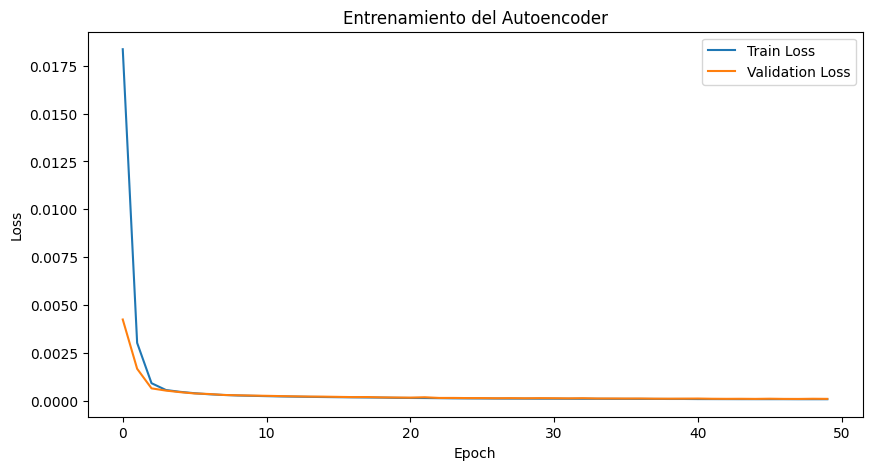

In [35]:
# ==========================================================
# CELDA 12 - GRÁFICA DE ENTRENAMIENTO
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Entrenamiento del Autoencoder')

plt.legend()

plt.show()

In [54]:
# ==========================================================
# CELDA 13 - ERROR DE RECONSTRUCCIÓN TRAIN
# ==========================================================

# Reconstrucción train
train_predictions = autoencoder.predict(X_train_scaled)

# MSE por muestra
train_mse = np.mean(
    np.power(X_train_scaled - train_predictions, 2),
    axis=1
)

print("Primeros 10 valores de MSE:\n")

print(train_mse[:10])

print("\nPromedio:", np.mean(train_mse))

print("Mínimo:", np.min(train_mse))

print("Máximo:", np.max(train_mse))

5272/5272 ━━━━━━━━━━━━━━━━━━━━ 4s 659us/step
Primeros 10 valores de MSE:

[1.7767101e-04 2.4573667e-06 2.1997225e-06 4.9701416e-06 6.7095548e-06
 5.8689762e-05 4.7795238e-06 1.3673746e-05 2.2663664e-06 7.7226023e-06]

Promedio: 8.546854e-05
Mínimo: 7.012498e-07
Máximo: 0.20051976


In [55]:
# ==========================================================
# CELDA 14 - DEFINIR THRESHOLD
# ==========================================================

# Threshold más sensible
threshold = np.percentile(train_mse, 80)

print("Threshold:", threshold)

Threshold: 6.0069586e-05


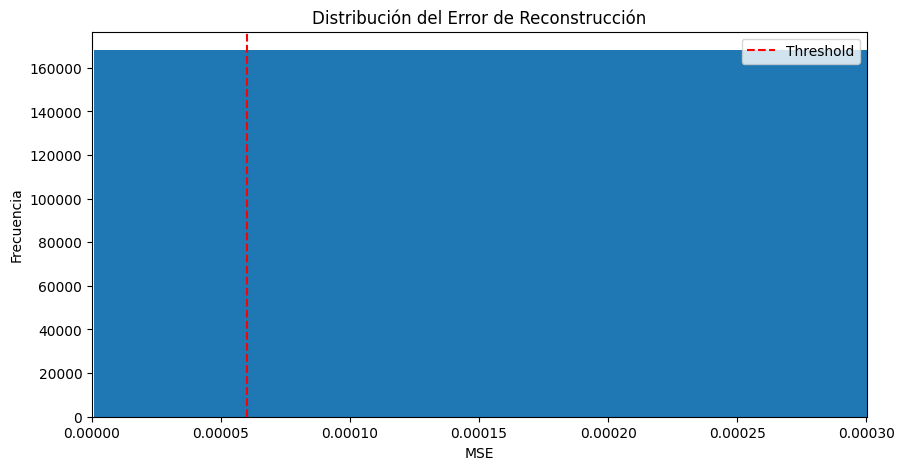

In [53]:
# ==========================================================
# CELDA 15 - HISTOGRAMA DEL MSE
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    train_mse,
    bins=100
)

plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

# Zoom para ver mejor la distribución
plt.xlim(0, threshold * 5)

plt.xlabel('MSE')

plt.ylabel('Frecuencia')

plt.title('Distribución del Error de Reconstrucción')

plt.legend()

plt.show()

In [47]:
# ==========================================================
# CELDA 16 - EVALUACIÓN EN TEST
# ==========================================================

# Reconstrucción test
test_predictions = autoencoder.predict(X_test_scaled)

# MSE por muestra
test_mse = np.mean(
    np.power(X_test_scaled - test_predictions, 2),
    axis=1
)

print("MSE Test calculado.")

26860/26860 ━━━━━━━━━━━━━━━━━━━━ 17s 642us/step
MSE Test calculado.


In [48]:
# ==========================================================
# CELDA 17 - CLASIFICACIÓN FINAL
# ==========================================================

# 1 = Ataque
# 0 = Normal

y_pred = (test_mse > threshold).astype(int)

# Etiquetas reales
y_true = np.where(
    y_test == "Benign",
    0,
    1
)

print("Clasificación completada.")

Clasificación completada.


In [49]:
# ==========================================================
# CELDA 18 - MATRIZ DE CONFUSIÓN
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Matriz de Confusión:\n")

print(cm)

Matriz de Confusión:

[[ 57945  14355]
 [173255 613959]]


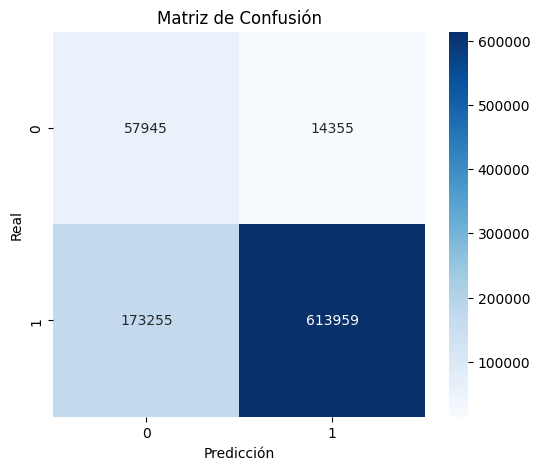

In [50]:
# ==========================================================
# CELDA 19 - MATRIZ DE CONFUSIÓN VISUAL
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.title("Matriz de Confusión")

plt.show()

In [51]:
# ==========================================================
# CELDA 20 - MÉTRICAS
# ==========================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

print(f"Recall: {recall:.4f}")

print(f"F1-Score: {f1:.4f}")

Accuracy: 0.7817
Recall: 0.7799
F1-Score: 0.8675


In [52]:
# ==========================================================
# CELDA 21 - REPORTE COMPLETO
# ==========================================================

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.25      0.80      0.38     72300
           1       0.98      0.78      0.87    787214

    accuracy                           0.78    859514
   macro avg       0.61      0.79      0.62    859514
weighted avg       0.92      0.78      0.83    859514

